In [44]:
# 2. Inspeccione la estructura de carpetas del dataset e identifique las clases disponibles. ¿Cuántas categorías distintas existen y cuáles son?
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import os

path_to_dataset = '../data/dataset-resized'
folders = sorted(os.listdir(path_to_dataset))
folders = [folder for folder in folders if folder != '.DS_Store']
# print(folders)

print(f'Categorias: {folders} | Total de categorias: {len(folders)}')

Categorias: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'] | Total de categorias: 6


In [7]:
# 3. Calcule el número total de imágenes presentes en el dataset. Compare el resultado con la cantidad
# reportada por la fuente original.

total_imagenes = 0
df = []

for folder in folders:
    path_to_categoria = path_to_dataset + "/" + folder
    imagenes = sorted(os.listdir(path_to_categoria))
    imagenes = [img for img in imagenes if img.endswith(".jpg")]
    total_imagenes += len(imagenes)
    print(f"Categoria: {folder} - Total de muestras: {len(imagenes)}")

    df.append({
        "categoria": folder,
        "total_imagenes": len(imagenes)
    })

print(f"Total de imagenes: {total_imagenes}")

Categoria: cardboard - Total de muestras: 403
Categoria: glass - Total de muestras: 501
Categoria: metal - Total de muestras: 410
Categoria: paper - Total de muestras: 594
Categoria: plastic - Total de muestras: 482
Categoria: trash - Total de muestras: 137
Total de imagenes: 2527


In [8]:
# 4. Calcule la cantidad de imágenes por clase y presente los resultados en una tabla ordenada de mayor
# a menor frecuencia.
df = pd.DataFrame(df).sort_values("total_imagenes", ascending=False)
df.head(10)

,categoria,total_imagenes
3,paper,594
1,glass,501
4,plastic,482
2,metal,410
0,cardboard,403
5,trash,137


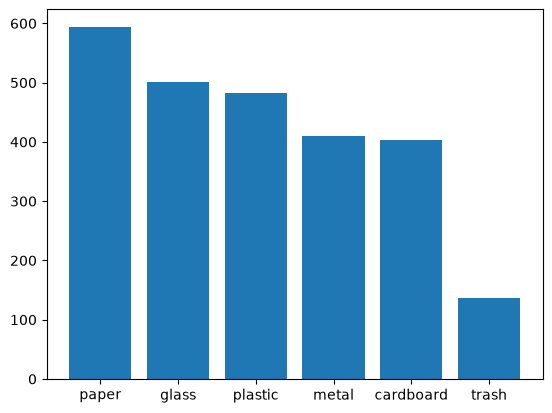

In [9]:
# 5. Visualice la distribución de imágenes por clase mediante un gráfico de barras. ¿El dataset está
# balanceado? Justifique su respuesta.
plt.bar(df["categoria"], df["total_imagenes"])
plt.show()

In [10]:
# 6. Calcule el porcentaje que representa cada clase respecto del total. Determine la clase mayoritaria, la
# minoritaria y la razón de desbalance entre ambas.
df["porcentaje"] = (df["total_imagenes"] / df["total_imagenes"].sum()) * 100

clase_mayoritaria = df["porcentaje"].idxmax()
clase_minoritaria = df["porcentaje"].idxmin()

clase_mayoritaria_tot_imgs = df.loc[clase_mayoritaria]["total_imagenes"]
clase_minoritaria_tot_imgs = df.loc[clase_minoritaria]["total_imagenes"]

razon = clase_mayoritaria_tot_imgs / clase_minoritaria_tot_imgs
print("Razon: ", razon)
df.head(10)

Razon:  4.335766423357664


,categoria,total_imagenes,porcentaje
3,paper,594,23.506134
1,glass,501,19.825880
4,plastic,482,19.074001
2,metal,410,16.224772
0,cardboard,403,15.947764
5,trash,137,5.421448


In [11]:
# 7. Verifique programáticamente que todas las imágenes puedan abrirse correctamente. ¿Existen
# archivos corruptos o ilegibles?

# uv add pillow -> instalar pillow
from PIL import Image
from pathlib import Path


all_images = []
clases = []
formatos = []
sizes_kb = []

for folder in folders:
    path_to_categoria = path_to_dataset + "/" + folder
    imagenes = sorted(os.listdir(path_to_categoria))
    formatos.extend([img.split(".")[-1] for img in imagenes])
    imagenes = [img for img in imagenes if img.endswith(".jpg")]
    rutas = [path_to_categoria + "/" + img for img in imagenes]
    sizes_kb.extend([Path(ruta).stat().st_size / 1024 for ruta in rutas])
    all_images.extend(rutas)
    clases.extend([folder] * len(rutas))

metadata_df = pd.DataFrame({
    "ruta": all_images,
    "clase": clases,
    "formato": formatos,
    "size_kb": sizes_kb
})

corruptos = []
for ruta_img in all_images:
    try:
        img = Image.open(ruta_img)
        img.verify()
    except:
        corruptos.append(ruta_img)

print(f"Archivos corruptos: {corruptos}")

Archivos corruptos: []


In [12]:
metadata_df

,ruta,clase,formato,size_kb
0,../data/dataset-resized/cardboard/cardboard1.jpg,cardboard,jpg,16.926758
1,../data/dataset-resized/cardboard/cardboard10.jpg,cardboard,jpg,21.174805
2,../data/dataset-resized/cardboard/cardboard100...,cardboard,jpg,14.535156
3,../data/dataset-resized/cardboard/cardboard101...,cardboard,jpg,13.954102
4,../data/dataset-resized/cardboard/cardboard102...,cardboard,jpg,17.592773
...,...,...,...,...
2522,../data/dataset-resized/trash/trash95.jpg,trash,jpg,7.377930
2523,../data/dataset-resized/trash/trash96.jpg,trash,jpg,16.273438
2524,../data/dataset-resized/trash/trash97.jpg,trash,jpg,8.920898
2525,../data/dataset-resized/trash/trash98.jpg,trash,jpg,14.216797


In [13]:
# 8. Identifique las extensiones o formatos de archivo presentes en el dataset y calcule su frecuencia.
metadata_df["formato"].value_counts()

formato
jpg    2527
Name: count, dtype: int64

In [14]:
# 9. Calcule el tamaño de cada archivo en kilobytes. Obtenga estadísticas descriptivas globales del
# tamaño de archivo y compárelas entre clases.
metadata_df["size_kb"].describe()

count    2527.000000
mean       16.726542
std         7.420650
min         5.472656
25%        11.628418
50%        15.024414
75%        19.827148
max        56.511719
Name: size_kb, dtype: float64

In [15]:
metadata_df

,ruta,clase,formato,size_kb
0,../data/dataset-resized/cardboard/cardboard1.jpg,cardboard,jpg,16.926758
1,../data/dataset-resized/cardboard/cardboard10.jpg,cardboard,jpg,21.174805
2,../data/dataset-resized/cardboard/cardboard100...,cardboard,jpg,14.535156
3,../data/dataset-resized/cardboard/cardboard101...,cardboard,jpg,13.954102
4,../data/dataset-resized/cardboard/cardboard102...,cardboard,jpg,17.592773
...,...,...,...,...
2522,../data/dataset-resized/trash/trash95.jpg,trash,jpg,7.377930
2523,../data/dataset-resized/trash/trash96.jpg,trash,jpg,16.273438
2524,../data/dataset-resized/trash/trash97.jpg,trash,jpg,8.920898
2525,../data/dataset-resized/trash/trash98.jpg,trash,jpg,14.216797


In [16]:
metadata_df.groupby("clase")["size_kb"].agg(["count", "mean", "median", "min", "max"])

,count,mean,median,min,max
clase,,,,,
cardboard,403,18.429552,18.474609,7.542969,34.099609
glass,501,13.011202,12.446289,5.472656,33.013672
metal,410,17.323576,16.184082,6.097656,49.162109
paper,594,21.115726,17.900879,6.347656,56.511719
plastic,482,14.072888,13.559082,5.847656,31.220703
trash,137,13.822700,13.068359,6.375000,35.428711


In [18]:

anchos = []
altos = []

for path_img in metadata_df['ruta']:
    img = Image.open(path_img)
    ancho, alto = img.size
    anchos.append(ancho)
    altos.append(alto)


metadata_df['dim_ancho'] = anchos
metadata_df['dim_alto'] = altos

(metadata_df['dim_ancho'].astype(str) + ' x ' + metadata_df['dim_alto'].astype(str)).value_counts()

512 x 384    2527
Name: count, dtype: int64

In [19]:
metadata_df['ratio_aspecto'] = metadata_df['dim_ancho'] / metadata_df['dim_alto']
metadata_df['ratio_aspecto'].value_counts()

ratio_aspecto
1.333333    2527
Name: count, dtype: int64

In [34]:
num_canales = []

for path_img in metadata_df['ruta']:
    img = Image.open(path_img)
    mode = img.mode
    num_canales.append(mode)

metadata_df['num_canales'] = num_canales
metadata_df.head(10)


metadata_df['num_canales'].value_counts()

num_canales
RGB    2527
Name: count, dtype: int64

NameError: name 'class_labels' is not defined

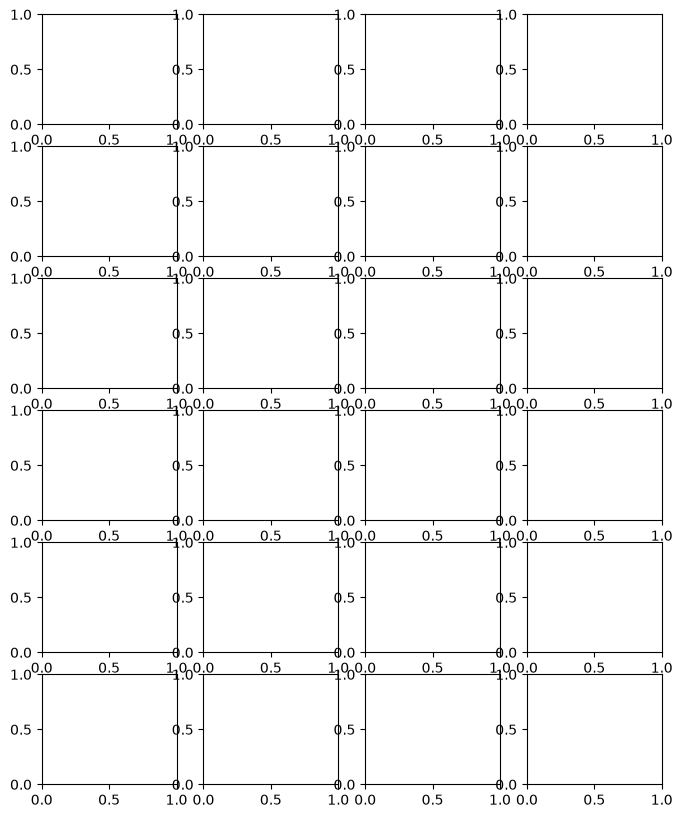

In [37]:

import random

def show_imagenes_random(dataframe, n_imgs_per_class = 4, seed = 42):
    random.seed(seed)
    clases_unicas = sorted(dataframe['clase'].unique())
    paths = []
    class_label = []
    for clase_unica in clases_unicas:
        paths.extend(
            random.sample(metadata_df[metadata_df['clase'] == clase_unica]['ruta'].to_list(), 4)
        )
        class_label.extend([clase_unica] * n_imgs_per_class)

    fig, axes = plt.subplots(
        len(clases_unicas),
        n_imgs_per_class,
        figsize = (8, 10)
    )

    for row, (path, class_label) in enumerate(zip(paths, class_labels)):
        for col, (p, cl) in enumerate(zip(path, class_label)):
            img = Image.open(p)
            axes[row, col].imshow(img)
            axes[row, col].set_title(cl)
            axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

show_imagenes_random(metadata_df)

In [40]:
import numpy as np

mean_r = []
mean_g = []
mean_b = []

for path_img in metadata_df['ruta']:
    img = np.array(Image.open(path_img))
    # plt.imshow(img)
    mean_r.append(img[:, :, 0].mean())
    mean_g.append(img[:, :, 1].mean())
    mean_b.append(img[:, :, 2].mean())

metadata_df['mean_r'] = mean_r
metadata_df['mean_g'] = mean_g
metadata_df['mean_b'] = mean_b

metadata_df.groupby('clase')[['mean_r', 'mean_g', 'mean_b']].mean()
   

,mean_r,mean_g,mean_b
clase,,,
cardboard,170.080264,148.857001,127.931290
glass,176.375375,170.518422,163.098047
metal,164.828272,157.005761,151.896572
paper,172.181150,164.551183,155.431459
plastic,171.084918,170.091793,168.978540
trash,178.804079,166.113023,149.045881


In [ ]:
for canal in ['mean_r', 'mean_g', 'mean_b']:
    plt.figure(figsize=(8, 4))
    grupos =[
        metadata_df.loc[metadata_df['clase'] == clase, canal].astype
        for clase in metadata_df['clase'].unique()
    ]



<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

<Figure size 800x400 with 0 Axes>

../data/dataset-resized/cardboard/cardboard1.jpg


AttributeError: 'Axes' object has no attribute 'smshow'

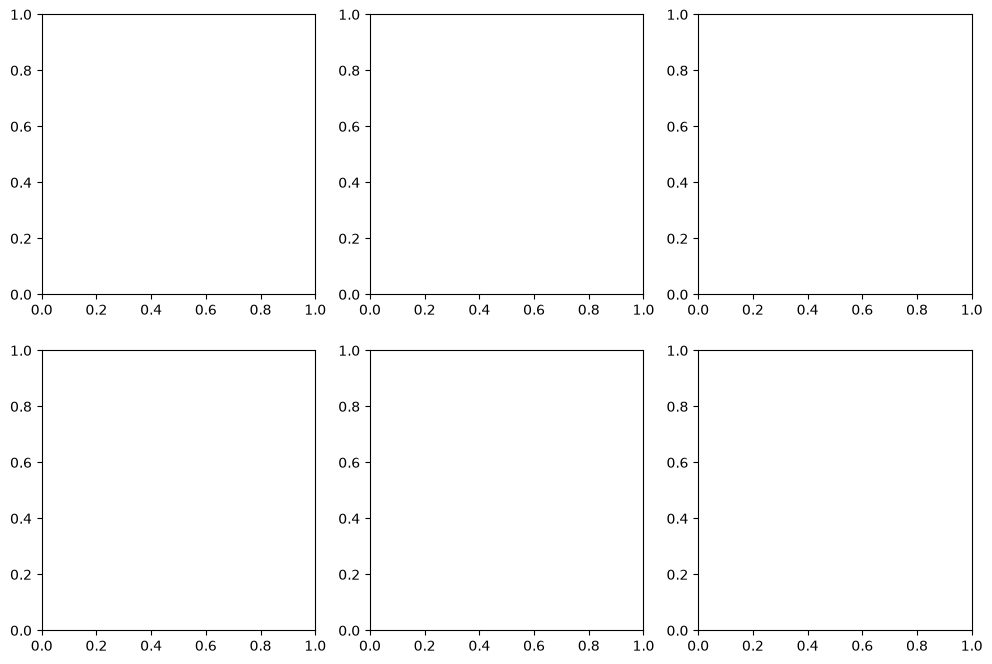

In [47]:

def mean_image(paths, size=(512, 384)):
    acc = np.zeros((512, 384, 3))
    for path in paths:
        print(path)
        break

        return np.clip(acc / len(paths),0 , 255).astype(np.uint8)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for clase, ax in zip(metadata_df['clase'].unique(), axes.ravel()):
    avg = mean_image(metadata_df[metadata_df['clase'] == clase]['ruta'])
    ax.smshow(avg)
    ax.set_title(clase)
    ax.axis('off')


plt.tight_layout()
plt.show()